# Phase 1 ver4 — 실험 결과 종합 분석

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──
nanum = [f.fname for f in fm.fontManager.ttflist if 'NanumGothic' in f.name]
noto  = [f.fname for f in fm.fontManager.ttflist if 'NotoSansCJK' in f.name or 'Noto Sans CJK' in f.name]

if nanum:
    plt.rcParams['font.family'] = 'NanumGothic'
elif noto:
    plt.rcParams['font.family'] = 'Noto Sans CJK KR'
else:
    print('⚠️ 한국어 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.')

plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ──
NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..'))
RESULTS_ROOT  = os.path.join(PROJECT_ROOT, 'results', 'phase1_ver4')

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'RESULTS_ROOT : {RESULTS_ROOT}')

# ── 스타일 설정 ──
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── 상수 ──
DATASETS = ['humaneval']
METHODS  = ['single', 'retry', 'repair','code_then_plan','code_then_plan_repair','policy_loop']
METHOD_LABELS = {
    'single'   : 'Single Shot',
    'retry'    : 'Retry Only',
    'repair'   : 'Repair Loop',
    'planner_coder' : 'Planner-Coder',
    'code_then_plan' : 'Code-Then-Plan',
    'code_then_plan_repair' : 'Code-Then-Plan+Repair',
    'policy_loop' : 'Policy Loop'
}

# ── 색상 팔레트 ──
METHOD_COLORS = {
    'single'        : '#4C72B0',
    'retry'         : '#DD8452',
    'repair'       : '#55A868',
    'planner_coder'        : '#C44E52',
    'code_then_plan' : '#8172B2',
    'code_then_plan_repair' : '#9EDDFF',
    'policy_loop' : '#FFA500'
}

PROJECT_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration
RESULTS_ROOT : /home/dibaeck/workspace/project_IR_focus_sLM_orchestration/results/phase1_ver4


---
## 1. 데이터 로드

In [2]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_jsonl(path):
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

# ── 결과 로드 ──
summaries          = {}   # (dataset, method) -> summary dict
analyses           = {}   # (dataset, method) -> analysis dict
step_logs_all      = {}   # (dataset, method) -> list of step records
traj_logs_all      = {}   # (dataset, method) -> list of trajectory records
failure_examples_all = {} # (dataset, method) -> dict of failure examples

found = []
missing = []

for dataset in DATASETS:
    for method in METHODS:
        base = os.path.join(RESULTS_ROOT, dataset, method)
        summary_path = os.path.join(base, 'summary.json')
        if os.path.exists(summary_path):
            key = (dataset, method)
            summaries[key]     = load_json(summary_path)
            analyses[key]      = load_json(os.path.join(base, 'analysis.json'))
            step_logs_all[key] = load_jsonl(os.path.join(base, 'step_logs.jsonl'))
            traj_logs_all[key] = load_jsonl(os.path.join(base, 'trajectory_logs.jsonl'))
            
            fe_path = os.path.join(base, 'failure_examples.json')
            if os.path.exists(fe_path):
                failure_examples_all[key] = load_json(fe_path)
            
            found.append(f'{dataset}/{method}')
        else:
            missing.append(f'{dataset}/{method}')

print(f'✅ 로드 성공 ({len(found)}개):', ', '.join(found))
if missing:
    print(f'⚠️  결과 없음 ({len(missing)}개):', ', '.join(missing))

✅ 로드 성공 (6개): humaneval/single, humaneval/retry, humaneval/repair, humaneval/code_then_plan, humaneval/code_then_plan_repair, humaneval/policy_loop


---
## 2. 핵심 지표 비교 (pass@1, exec_success_rate, conditional_pass)

In [3]:
# ── summary DataFrame 구성 ──
rows = []
for (dataset, method), s in summaries.items():
    if s is None:
        continue
    row = {
        'dataset'              : dataset,
        'method'               : method,
        'method_label'         : METHOD_LABELS.get(method, method),
        'total'                : s.get('total_problems', s.get('total', 0)),
        'num_pass'             : s.get('num_pass', s.get('passed', 0)),
        'pass@1'               : s.get('pass_at_1', s.get('pass@1', 0.0)),
        'exec_success_rate'    : s.get('execution_success_rate', 0.0),
        'conditional_pass'     : s.get('conditional_pass', 0.0),
        'avg_tokens'           : s.get('avg_tokens', 0.0),
        'avg_latency'          : s.get('avg_latency', 0.0),
        'avg_calls'            : s.get('avg_calls', 0.0),
    }
    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary = df_summary.set_index(['dataset', 'method'])

# 방법 순서 고정
method_order = [m for m in METHODS if m in df_summary.index.get_level_values('method').unique()]

print('\n=== Summary DataFrame ===')
display(df_summary[['total', 'num_pass', 'pass@1', 'exec_success_rate', 'conditional_pass',
                     'avg_tokens', 'avg_latency', 'avg_calls']].round(4))


=== Summary DataFrame ===


total  num_pass  pass@1  exec_success_rate  \
dataset   method                                                              
humaneval single                   164       113  0.6890             0.8537   
          retry                    164       123  0.7500             0.7622   
          repair                   164       141  0.8598             0.8780   
          code_then_plan           164       143  0.8720             0.9695   
          code_then_plan_repair    164       147  0.8963             0.9695   
          policy_loop              164       153  0.9329             1.0000   

                                 conditional_pass  avg_tokens  avg_latency  \
dataset   method                                                             
humaneval single                           0.8071    290.6951       2.1335   
          retry                            0.9840   1068.2195       7.8914   
          repair                           0.9792   1089.7988       8.2038   
          code_then_plan                   0.8994    514.5427       3.3473   
          code_then_plan_repair            0.9245    722.6524       3.8238   
          policy_loop                      0.9329      0.0000       0.0000   

                                 avg_calls  
dataset   method                            
humaneval single                    1.0000  
          retry                     2.3780  
          repair                    1.9512  
          code_then_plan            1.6220  
          code_then_plan_repair     1.9390  
          policy_loop               0.0000

In [4]:
METRICS = ['pass@1', 'exec_success_rate', 'conditional_pass']
METRIC_LABELS = {
    'pass@1'            : 'pass@1',
    'exec_success_rate' : 'Exec Success Rate',
    'conditional_pass'  : 'Conditional Pass',
}

for dataset in DATASETS:
    if dataset not in df_summary.index.get_level_values('dataset'):
        continue
    sub = df_summary.loc[dataset, METRICS].copy()
    # 방법 순서 정렬
    sub = sub.reindex([m for m in METHODS if m in sub.index])
    sub.index = [METHOD_LABELS.get(m, m) for m in sub.index]
    sub.columns = [METRIC_LABELS[c] for c in sub.columns]

    print(f'\n=== {dataset.upper()} ========================')
    display(sub.style
               .format('{:.4f}')
               .background_gradient(cmap='YlGn', axis=0))


=== HUMANEVAL ========================


,pass@1,Exec Success Rate,Conditional Pass
Single Shot,0.6890,0.8537,0.8071
Retry Only,0.7500,0.7622,0.9840
Repair Loop,0.8598,0.8780,0.9792
Code-Then-Plan,0.8720,0.9695,0.8994
Code-Then-Plan+Repair,0.8963,0.9695,0.9245
Policy Loop,0.9329,1.0000,0.9329


---
## 3. 방법별 비교 시각화

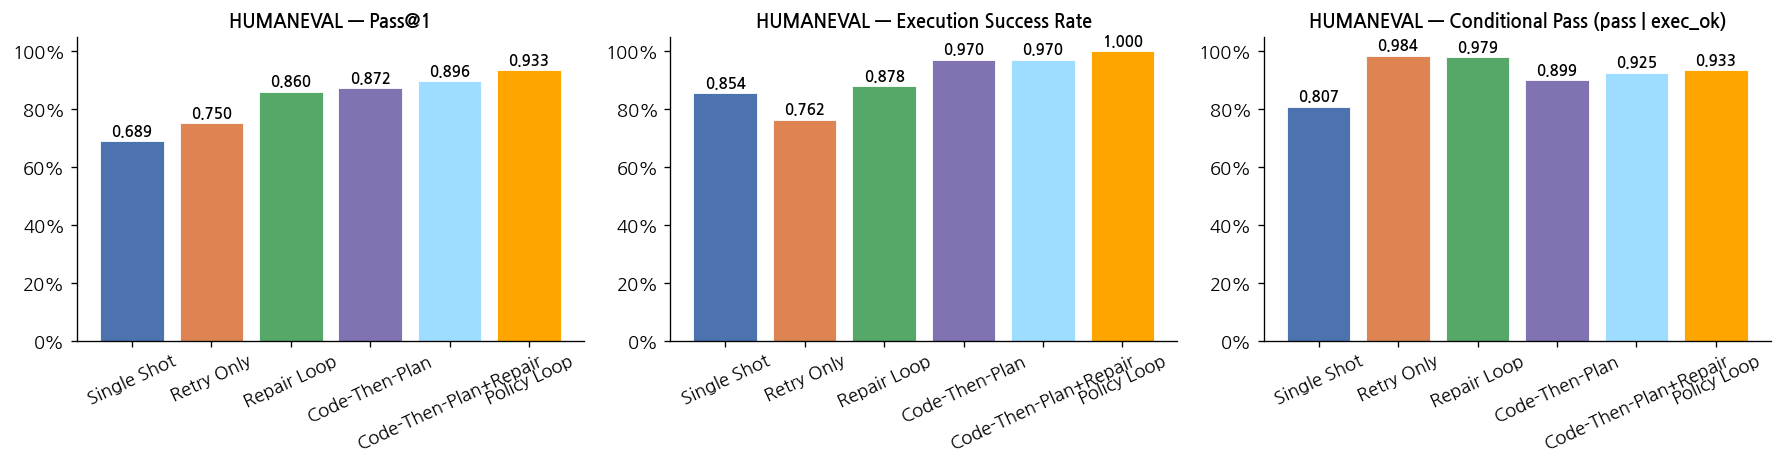

📊 ver4_metrics_comparison.png 저장 완료


In [5]:
rows = []
for (dataset, method), s in summaries.items():
    rows.append({
        'dataset': dataset,
        'method': method,
        'method_label': METHOD_LABELS.get(method, method),
        'total': s.get('total_problems', s.get('total', 0)),
        'pass': s.get('num_pass', s.get('passed', 0)),
        'pass@1': s.get('pass_at_1', s.get('pass@1', 0)),
        'exec_success_rate': s.get('execution_success_rate', 0),
        'conditional_pass': s.get('conditional_pass', 0),
        'avg_tokens': s.get('avg_tokens', 0),
        'avg_latency': s.get('avg_latency', 0),
        'avg_calls': s.get('avg_calls', 0),
    })

df_summary = pd.DataFrame(rows)

metrics_to_plot = ['pass@1', 'exec_success_rate', 'conditional_pass']
metric_titles = {
    'pass@1': 'Pass@1',
    'exec_success_rate': 'Execution Success Rate',
    'conditional_pass': 'Conditional Pass (pass | exec_ok)',
}

available_datasets = [d for d in DATASETS if any((d,m) in summaries for m in METHODS)]

fig, axes = plt.subplots(len(available_datasets), len(metrics_to_plot),
                         figsize=(5 * len(metrics_to_plot), 4 * len(available_datasets)),
                         squeeze=False)

for row_idx, dataset in enumerate(available_datasets):
    df_ds = df_summary[df_summary['dataset'] == dataset].copy()
    if df_ds.empty:
        continue
    
    for col_idx, metric in enumerate(metrics_to_plot):
        ax = axes[row_idx, col_idx]
        colors = [METHOD_COLORS.get(m, '#999999') for m in df_ds['method']]
        bars = ax.bar(df_ds['method_label'], df_ds[metric], color=colors, edgecolor='white', linewidth=0.5)
        
        # 값 표시
        for bar, val in zip(bars, df_ds[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        ax.set_title(f'{dataset.upper()} — {metric_titles[metric]}', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(os.path.join(NOTEBOOK_DIR, 'ver4_metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('📊 ver4_metrics_comparison.png 저장 완료')

---
## 4. Failure Type 분석

In [6]:
# 4-1. failure_type_counts (analysis.json)
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'📌 {dataset.upper()} — Failure Type Counts')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in analyses:
            continue
        ftc = analyses[key].get('failure_type_counts', {})
        if not ftc:
            print(f'  {METHOD_LABELS[method]}: (failure 없음)')
            continue
        print(f'\n  {METHOD_LABELS[method]}:')
        for ftype, count in sorted(ftc.items(), key=lambda x: -x[1]):
            print(f'    {ftype}: {count}')


📌 HUMANEVAL — Failure Type Counts

  Single Shot:
    TEST_FAIL:AssertionError: 25
    EXEC_FAIL:SyntaxError: 17
    EXEC_FAIL:NameError: 3
    EXEC_FAIL:AssertionError: 2
    TEST_FAIL:ValueError: 1
    EXEC_FAIL:TypeError: 1
    EXEC_FAIL:ValueError: 1
    TEST_FAIL:NameError: 1

  Retry Only:
    EXEC_FAIL:NameError: 122
    EXEC_FAIL:SyntaxError: 89
    TEST_FAIL:AssertionError: 32
    CODE_FAIL:empty_output: 17
    EXEC_FAIL:AssertionError: 2
    EXEC_FAIL:TypeError: 1
    TEST_FAIL:ValueError: 1
    EXEC_FAIL:ValueError: 1
    TEST_FAIL:NameError: 1
    TEST_FAIL:TypeError: 1

  Repair Loop:
    EXEC_FAIL:NameError: 64
    EXEC_FAIL:SyntaxError: 56
    TEST_FAIL:AssertionError: 51
    TEST_FAIL:NameError: 3
    EXEC_FAIL:AssertionError: 1
    EXEC_FAIL:RecursionError: 1
    EXEC_FAIL:TypeError: 1
    TEST_FAIL:IndexError: 1
    EXEC_FAIL:IndentationError: 1

  Code-Then-Plan:
    TEST_FAIL:AssertionError: 35
    EXEC_FAIL:SyntaxError: 22
    EXEC_FAIL:NameError: 4
    TEST_FAIL:

In [7]:
# 4-2. failure_family_counts (analysis.json)
print('\n' + '=' * 60)
print('📌 Failure Family Counts (coarse-grained)')
print('=' * 60)

family_rows = []
for (dataset, method), a in analyses.items():
    ffc = a.get('failure_family_counts', {})
    for family, count in ffc.items():
        family_rows.append({
            'dataset': dataset,
            'method': METHOD_LABELS.get(method, method),
            'failure_family': family,
            'count': count,
        })

if family_rows:
    df_family = pd.DataFrame(family_rows)
    pivot_family = df_family.pivot_table(
        index=['dataset', 'method'], columns='failure_family',
        values='count', fill_value=0, aggfunc='sum'
    )
    display(pivot_family)
else:
    print('  (failure_family_counts 데이터 없음)')


📌 Failure Family Counts (coarse-grained)


failure_family                   CODE_FAIL  EXEC_FAIL  TEST_FAIL
dataset   method                                                
humaneval Code-Then-Plan                 0         30         42
          Code-Then-Plan+Repair          0         34         89
          Repair Loop                    0        124         55
          Retry Only                    17        215         35
          Single Shot                    0         24         27

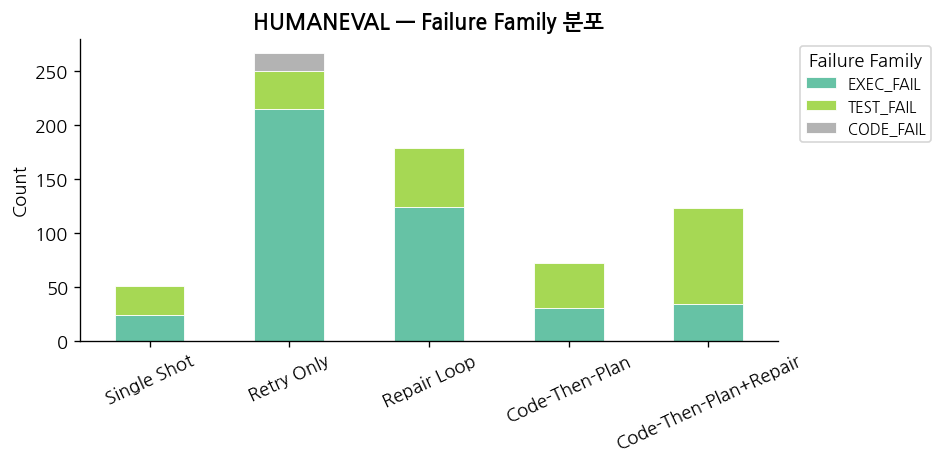

In [8]:
# 4-3. Failure Family 시각화 (Stacked Bar)
for dataset in available_datasets:
    family_data = {}
    for method in METHODS:
        key = (dataset, method)
        if key not in analyses:
            continue
        ffc = analyses[key].get('failure_family_counts', {})
        if ffc:
            family_data[METHOD_LABELS[method]] = ffc
    
    if not family_data:
        continue
    
    df_fam = pd.DataFrame(family_data).T.fillna(0)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    df_fam.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
    ax.set_title(f'{dataset.upper()} — Failure Family 분포', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Failure Family', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 5. Transition Path 분석 (retry / repair / planner_coder)

In [9]:
# 5-1. Transition Sequences (step) 테이블

def extract_sequence_counts(traj_logs, pattern_len=5):
    seq_counts = {}

    for traj in traj_logs:
        path = traj.get('transition_path', [])
        coarse_path = [p.split(':')[0] for p in path]

        if len(coarse_path) < pattern_len:
            continue

        for i in range(len(coarse_path) - pattern_len + 1):
            seq = tuple(coarse_path[i:i+pattern_len])
            seq_counts[seq] = seq_counts.get(seq, 0) + 1

    return seq_counts


for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'🔄 {dataset.upper()} — Transition Sequences (step)')
    print('=' * 60)

    for method in METHODS:
        key = (dataset, method)
        if key not in traj_logs_all:
            continue

        traj_logs = traj_logs_all[key]
        seq_counts = extract_sequence_counts(traj_logs, pattern_len=5)

        if not seq_counts:
            continue

        print(f'\n  {METHOD_LABELS[method]}:')
        for seq, count in sorted(seq_counts.items(), key=lambda x: -x[1]):
            seq_str = ' -> '.join(seq)
            print(f'    {seq_str}: {count}')


🔄 HUMANEVAL — Transition Sequences (step)

  Retry Only:
    EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL: 40
    TEST_FAIL -> EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL: 19
    EXEC_FAIL -> EXEC_FAIL -> CODE_FAIL -> EXEC_FAIL -> EXEC_FAIL: 4
    EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL -> CODE_FAIL -> EXEC_FAIL: 4
    EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL -> CODE_FAIL: 4
    TEST_FAIL -> TEST_FAIL -> TEST_FAIL -> TEST_FAIL -> TEST_FAIL: 2
    EXEC_FAIL -> TEST_FAIL -> EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL: 2
    EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL -> PASS: 1
    EXEC_FAIL -> CODE_FAIL -> EXEC_FAIL -> EXEC_FAIL -> EXEC_FAIL: 1
    TEST_FAIL -> TEST_FAIL -> CODE_FAIL -> CODE_FAIL -> EXEC_FAIL: 1
    TEST_FAIL -> CODE_FAIL -> CODE_FAIL -> EXEC_FAIL -> CODE_FAIL: 1
    TEST_FAIL -> EXEC_FAIL -> EXEC_FAIL -> TEST_FAIL -> EXEC_FAIL: 1
    EXEC_FAIL -> EXEC_FAIL -> TEST_FAIL -> EXEC_FAIL -> PASS: 1
    TEST_FAIL -> EXEC_FAIL -> EXEC_FAIL -> CODE_FAIL 

In [10]:
# 5-1. Planner 관련 Transition Sequences (step)만 출력

def extract_sequence_counts(traj_logs, pattern_len=5, must_include=None):
    seq_counts = {}

    for traj in traj_logs:
        path = traj.get('transition_path', [])
        coarse_path = [p.split(':')[0] for p in path]

        if len(coarse_path) < pattern_len:
            continue

        for i in range(len(coarse_path) - pattern_len + 1):
            seq = tuple(coarse_path[i:i+pattern_len])

            if must_include is not None and must_include not in seq:
                continue

            seq_counts[seq] = seq_counts.get(seq, 0) + 1

    return seq_counts


for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'🔄 {dataset.upper()} — Planner-related Sequences (3-step)')
    print('=' * 60)

    for method in METHODS:
        key = (dataset, method)
        if key not in traj_logs_all:
            continue

        traj_logs = traj_logs_all[key]
        seq_counts = extract_sequence_counts(
            traj_logs,
            pattern_len=3,          # 2
            must_include='PLAN_DONE'
        )

        if not seq_counts:
            continue

        print(f'\n  {METHOD_LABELS[method]}:')
        for seq, count in sorted(seq_counts.items(), key=lambda x: -x[1]):
            seq_str = ' -> '.join(seq)
            print(f'    {seq_str}: {count}')


🔄 HUMANEVAL — Planner-related Sequences (3-step)

  Code-Then-Plan:
    EXEC_FAIL -> PLAN_DONE -> PASS: 19
    TEST_FAIL -> PLAN_DONE -> TEST_FAIL: 13
    TEST_FAIL -> PLAN_DONE -> PASS: 11
    EXEC_FAIL -> PLAN_DONE -> EXEC_FAIL: 3
    EXEC_FAIL -> PLAN_DONE -> TEST_FAIL: 3
    TEST_FAIL -> PLAN_DONE -> EXEC_FAIL: 2

  Code-Then-Plan+Repair:
    EXEC_FAIL -> PLAN_DONE -> PASS: 14
    TEST_FAIL -> PLAN_DONE -> PASS: 13
    TEST_FAIL -> PLAN_DONE -> TEST_FAIL: 12
    PLAN_DONE -> TEST_FAIL -> TEST_FAIL: 12
    EXEC_FAIL -> PLAN_DONE -> TEST_FAIL: 5
    PLAN_DONE -> TEST_FAIL -> EXEC_FAIL: 3
    PLAN_DONE -> EXEC_FAIL -> TEST_FAIL: 3
    TEST_FAIL -> PLAN_DONE -> EXEC_FAIL: 3
    PLAN_DONE -> TEST_FAIL -> PASS: 2
    EXEC_FAIL -> PLAN_DONE -> EXEC_FAIL: 1
    PLAN_DONE -> EXEC_FAIL -> EXEC_FAIL: 1

  Policy Loop:
    TEST_FAIL -> PLAN_DONE -> TEST_FAIL: 32
    TEST_FAIL -> PLAN_DONE -> PASS: 26
    PLAN_DONE -> TEST_FAIL -> PLAN_DONE: 23
    TEST_FAIL -> TEST_FAIL -> PLAN_DONE: 12
    E

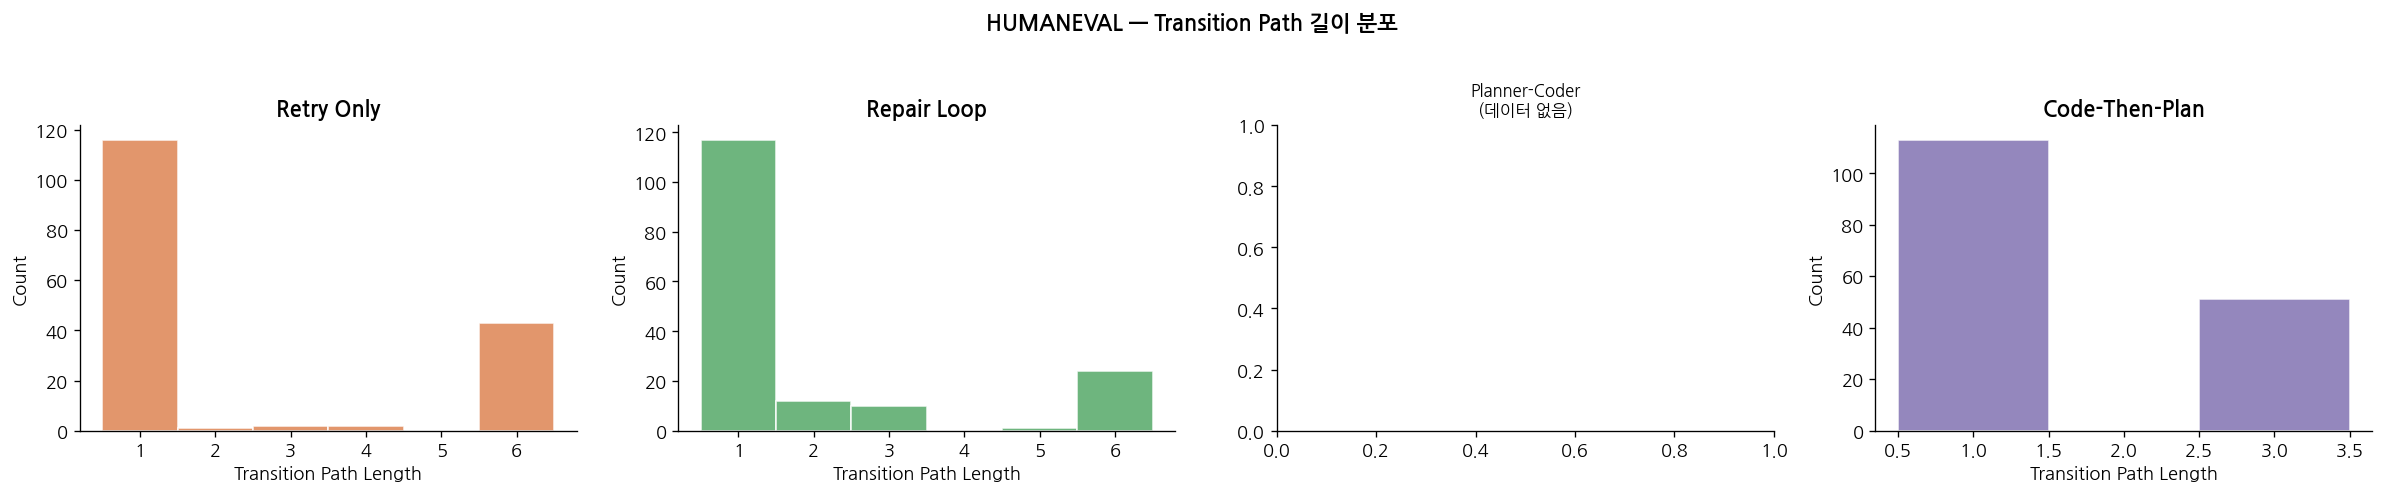

In [11]:
# 5-2. Transition Path 길이 분포 
multi_step_methods = ['retry', 'repair', 'planner_coder','code_then_plan']

for dataset in available_datasets:
    fig, axes_row = plt.subplots(1, len(multi_step_methods), figsize=(5 * len(multi_step_methods), 4), squeeze=False)
    has_data = False
    
    for col_idx, method in enumerate(multi_step_methods):
        ax = axes_row[0, col_idx]
        key = (dataset, method)
        if key not in traj_logs_all:
            ax.set_title(f'{METHOD_LABELS[method]}\n(데이터 없음)', fontsize=10)
            continue
        
        trajs = traj_logs_all[key]
        path_lens = [len(t.get('transition_path', [])) for t in trajs]
        
        if not path_lens:
            continue
        has_data = True
        
        ax.hist(path_lens, bins=range(1, max(path_lens) + 2), color=METHOD_COLORS.get(method, '#999'),
                edgecolor='white', alpha=0.85, align='left')
        ax.set_title(f'{METHOD_LABELS[method]}', fontweight='bold')
        ax.set_xlabel('Transition Path Length')
        ax.set_ylabel('Count')
    
    if has_data:
        fig.suptitle(f'{dataset.upper()} — Transition Path 길이 분포', fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

In [12]:
# 5-3. 최종 상태별 분포 (trajectory_logs의 final_status)
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'🎯 {dataset.upper()} — Final Status 분포')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in traj_logs_all:
            continue
        
        trajs = traj_logs_all[key]
        status_counts = {}
        for t in trajs:
            s = t.get('final_status', 'UNKNOWN')
            status_counts[s] = status_counts.get(s, 0) + 1
        
        print(f'\n  {METHOD_LABELS[method]} (n={len(trajs)}):')
        for s, c in sorted(status_counts.items(), key=lambda x: -x[1]):
            pct = c / len(trajs) * 100
            print(f'    {s}: {c} ({pct:.1f}%)')


🎯 HUMANEVAL — Final Status 분포

  Single Shot (n=164):
    PASS: 113 (68.9%)
    TEST_FAIL:AssertionError: 25 (15.2%)
    EXEC_FAIL:SyntaxError: 17 (10.4%)
    EXEC_FAIL:NameError: 3 (1.8%)
    EXEC_FAIL:AssertionError: 2 (1.2%)
    TEST_FAIL:ValueError: 1 (0.6%)
    EXEC_FAIL:TypeError: 1 (0.6%)
    EXEC_FAIL:ValueError: 1 (0.6%)
    TEST_FAIL:NameError: 1 (0.6%)

  Retry Only (n=164):
    PASS: 123 (75.0%)
    EXEC_FAIL:NameError: 24 (14.6%)
    EXEC_FAIL:SyntaxError: 11 (6.7%)
    CODE_FAIL:empty_output: 5 (3.0%)
    TEST_FAIL:AssertionError: 1 (0.6%)

  Repair Loop (n=164):
    PASS: 141 (86.0%)
    EXEC_FAIL:NameError: 15 (9.1%)
    EXEC_FAIL:SyntaxError: 5 (3.0%)
    TEST_FAIL:AssertionError: 2 (1.2%)
    TEST_FAIL:NameError: 1 (0.6%)

  Code-Then-Plan (n=164):
    PASS: 143 (87.2%)
    TEST_FAIL:AssertionError: 11 (6.7%)
    EXEC_FAIL:SyntaxError: 4 (2.4%)
    TEST_FAIL:TypeError: 2 (1.2%)
    EXEC_FAIL:NameError: 1 (0.6%)
    TEST_FAIL:ValueError: 1 (0.6%)
    TEST_FAIL:NameErr

---
## 6. 토큰 / 레이턴시 효율성 분석

In [13]:
# 6-1. 방법별 평균 토큰 / 레이턴시 / 호출 횟수 비교
efficiency_rows = []
for (dataset, method), trajs in traj_logs_all.items():
    tokens = [t.get('total_tokens', 0) for t in trajs]
    latencies = [t.get('total_latency', 0) for t in trajs]
    calls = [t.get('call_count', 0) for t in trajs]
    
    efficiency_rows.append({
        'dataset': dataset,
        'method': METHOD_LABELS.get(method, method),
        'avg_tokens': np.mean(tokens) if tokens else 0,
        'std_tokens': np.std(tokens) if tokens else 0,
        'avg_latency': np.mean(latencies) if latencies else 0,
        'std_latency': np.std(latencies) if latencies else 0,
        'avg_calls': np.mean(calls) if calls else 0,
        'med_tokens': np.median(tokens) if tokens else 0,
        'med_latency': np.median(latencies) if latencies else 0,
    })

df_eff = pd.DataFrame(efficiency_rows)
display(df_eff.style.format({
    'avg_tokens': '{:.1f}', 'std_tokens': '{:.1f}',
    'avg_latency': '{:.2f}', 'std_latency': '{:.2f}',
    'avg_calls': '{:.1f}',
    'med_tokens': '{:.1f}', 'med_latency': '{:.2f}',
}).set_caption('토큰 / 레이턴시 효율성'))

,dataset,method,avg_tokens,std_tokens,avg_latency,std_latency,avg_calls,med_tokens,med_latency
0,humaneval,Single Shot,290.7,120.7,2.13,1.20,1.0,263.5,1.86
1,humaneval,Retry Only,1068.2,1415.0,7.89,10.02,2.4,342.5,4.84
2,humaneval,Repair Loop,1089.8,1602.0,8.20,11.36,2.0,328.0,4.17
3,humaneval,Code-Then-Plan,514.5,377.6,3.35,2.18,1.6,349.0,2.84
4,humaneval,Code-Then-Plan+Repair,722.7,917.4,3.82,3.42,1.9,353.5,2.82
5,humaneval,Policy Loop,1053.8,1510.0,8.25,9.60,2.4,378.5,4.88


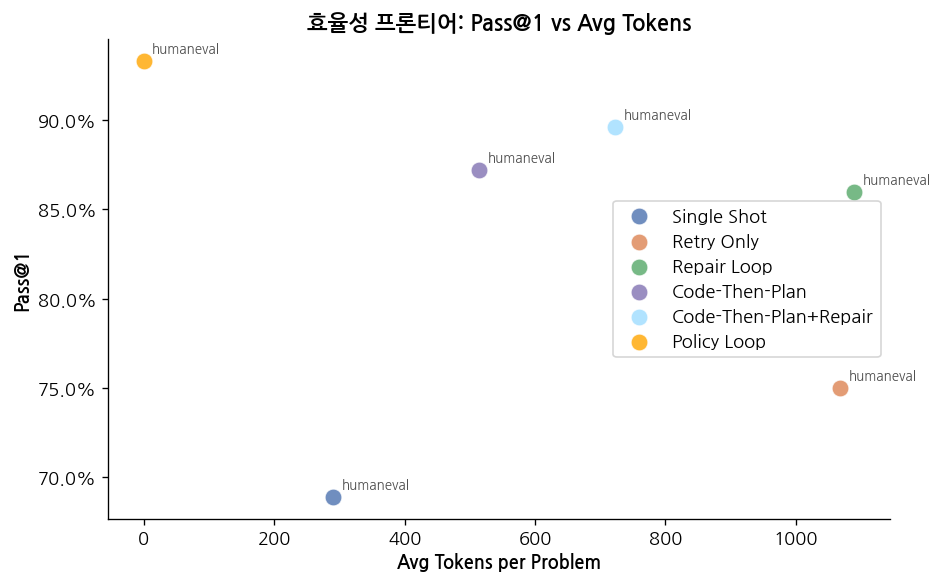

📊 ver4_efficiency_frontier.png 저장 완료


In [14]:
# 6-2. pass@1 vs avg_tokens 산점도 (효율성 프론티어)
if not df_summary.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for method in METHODS:
        df_m = df_summary[df_summary['method'] == method]
        if df_m.empty:
            continue
        ax.scatter(
            df_m['avg_tokens'], df_m['pass@1'],
            c=METHOD_COLORS.get(method, '#999'),
            s=100, alpha=0.8, edgecolors='white', linewidth=0.5,
            label=METHOD_LABELS[method], zorder=5,
        )
        # 데이터셋 라벨
        for _, row in df_m.iterrows():
            ax.annotate(row['dataset'], (row['avg_tokens'], row['pass@1']),
                       textcoords='offset points', xytext=(5, 5), fontsize=8, alpha=0.7)
    
    ax.set_xlabel('Avg Tokens per Problem', fontweight='bold')
    ax.set_ylabel('Pass@1', fontweight='bold')
    ax.set_title('효율성 프론티어: Pass@1 vs Avg Tokens', fontweight='bold')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    plt.tight_layout()
    plt.savefig(os.path.join(NOTEBOOK_DIR, 'ver4_efficiency_frontier.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('📊 ver4_efficiency_frontier.png 저장 완료')

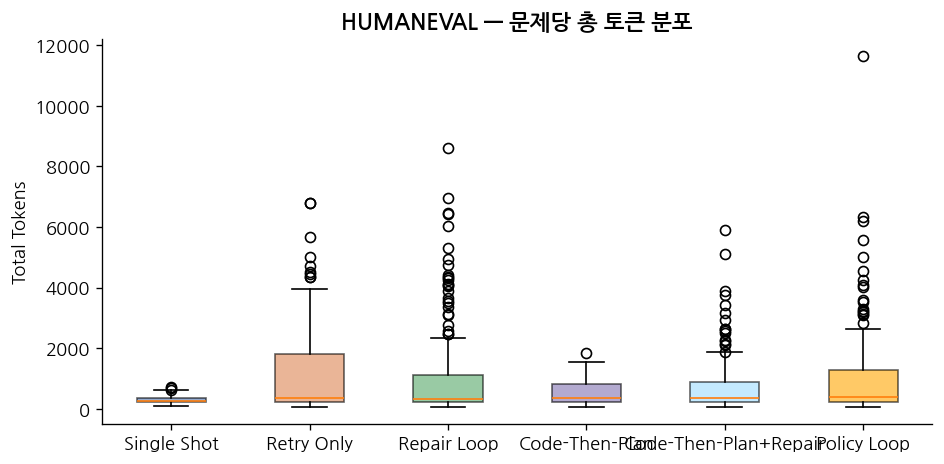

In [15]:
# 6-3. 토큰 분포 박스플롯
for dataset in available_datasets:
    token_data = {}
    for method in METHODS:
        key = (dataset, method)
        if key not in traj_logs_all:
            continue
        token_data[METHOD_LABELS[method]] = [t.get('total_tokens', 0) for t in traj_logs_all[key]]
    
    if not token_data:
        continue
    
    fig, ax = plt.subplots(figsize=(8, 4))
    bp = ax.boxplot(token_data.values(), labels=token_data.keys(), patch_artist=True)
    
    colors_list = [METHOD_COLORS.get(m, '#999') for m in METHODS if METHOD_LABELS[m] in token_data]
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_title(f'{dataset.upper()} — 문제당 총 토큰 분포', fontweight='bold')
    ax.set_ylabel('Total Tokens')
    plt.tight_layout()
    plt.show()

---
## 7. Step-level 상세 분석

In [16]:
# 7-1. Step별 상태 분포
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'📋 {dataset.upper()} — Step-level Status 분포')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in step_logs_all:
            continue
        
        steps = step_logs_all[key]
        status_counts = {}
        for s in steps:
            st = s.get('status', 'UNKNOWN')
            status_counts[st] = status_counts.get(st, 0) + 1
        
        total = len(steps)
        print(f'\n  {METHOD_LABELS[method]} (total steps: {total}):')
        for st, c in sorted(status_counts.items(), key=lambda x: -x[1]):
            pct = c / total * 100
            print(f'    {st}: {c} ({pct:.1f}%)')


📋 HUMANEVAL — Step-level Status 분포

  Single Shot (total steps: 164):
    PASS: 113 (68.9%)
    TEST_FAIL:AssertionError: 25 (15.2%)
    EXEC_FAIL:SyntaxError: 17 (10.4%)
    EXEC_FAIL:NameError: 3 (1.8%)
    EXEC_FAIL:AssertionError: 2 (1.2%)
    TEST_FAIL:ValueError: 1 (0.6%)
    EXEC_FAIL:TypeError: 1 (0.6%)
    EXEC_FAIL:ValueError: 1 (0.6%)
    TEST_FAIL:NameError: 1 (0.6%)

  Retry Only (total steps: 390):
    PASS: 123 (31.5%)
    EXEC_FAIL:NameError: 122 (31.3%)
    EXEC_FAIL:SyntaxError: 89 (22.8%)
    TEST_FAIL:AssertionError: 32 (8.2%)
    CODE_FAIL:empty_output: 17 (4.4%)
    EXEC_FAIL:AssertionError: 2 (0.5%)
    EXEC_FAIL:TypeError: 1 (0.3%)
    TEST_FAIL:ValueError: 1 (0.3%)
    EXEC_FAIL:ValueError: 1 (0.3%)
    TEST_FAIL:NameError: 1 (0.3%)
    TEST_FAIL:TypeError: 1 (0.3%)

  Repair Loop (total steps: 320):
    PASS: 141 (44.1%)
    EXEC_FAIL:NameError: 64 (20.0%)
    EXEC_FAIL:SyntaxError: 56 (17.5%)
    TEST_FAIL:AssertionError: 51 (15.9%)
    TEST_FAIL:NameError: 

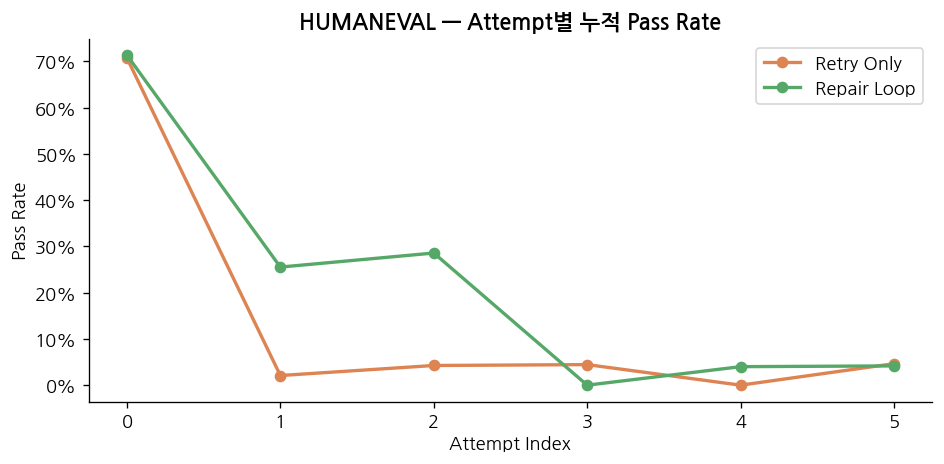

In [17]:
# 7-2. Step별 attempt_idx에 따른 Pass Rate 변화 
multi_step_methods_for_curve = ['retry', 'repair']

for dataset in available_datasets:
    fig, ax = plt.subplots(figsize=(8, 4))
    has_data = False
    
    for method in multi_step_methods_for_curve:
        key = (dataset, method)
        if key not in step_logs_all:
            continue
        
        steps = step_logs_all[key]
        # step_id (= attempt_idx)별 pass rate
        attempt_groups = {}
        for s in steps:
            if s.get('is_planner'):
                continue
            sid = s.get('step_id', s.get('call_index', 0))
            if sid not in attempt_groups:
                attempt_groups[sid] = {'pass': 0, 'total': 0}
            attempt_groups[sid]['total'] += 1
            if s.get('status') == 'PASS':
                attempt_groups[sid]['pass'] += 1
        
        if not attempt_groups:
            continue
        has_data = True
        
        xs = sorted(attempt_groups.keys())
        rates = [attempt_groups[x]['pass'] / attempt_groups[x]['total'] for x in xs]
        
        ax.plot(xs, rates, 'o-', color=METHOD_COLORS.get(method, '#999'),
                label=METHOD_LABELS[method], linewidth=2, markersize=6)
    
    if has_data:
        ax.set_title(f'{dataset.upper()} — Attempt별 누적 Pass Rate', fontweight='bold')
        ax.set_xlabel('Attempt Index')
        ax.set_ylabel('Pass Rate')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        ax.legend()
        ax.set_xticks(range(max(xs) + 1) if 'xs' in dir() else range(5))
        plt.tight_layout()
        plt.show()

In [18]:
# 7-3. Step별 토큰 사용량 히트맵
for dataset in available_datasets:
    for method in multi_step_methods_for_curve:
        key = (dataset, method)
        if key not in step_logs_all:
            continue
        
        steps = step_logs_all[key]
        df_steps = pd.DataFrame(steps)
        
        if df_steps.empty or 'step_id' not in df_steps.columns:
            continue
        
        # planner step 제외
        df_code = df_steps[df_steps.get('is_planner', False) != True].copy()
        
        if df_code.empty:
            continue
        
        print(f'\n{dataset.upper()} / {METHOD_LABELS[method]} — Step별 평균 토큰:')
        grouped = df_code.groupby('step_id').agg({
            'total_tokens': ['mean', 'std', 'count'],
            'latency_sec': ['mean', 'std'],
        }).round(1)
        display(grouped)


HUMANEVAL / Retry Only — Step별 평균 토큰:


total_tokens              latency_sec     
                mean    std count        mean  std
step_id                                           
0              301.3  123.2   164         4.5  2.5
1              687.8  293.9    48         4.0  4.4
2              551.7  300.0    47         2.3  3.4
3              514.1  265.5    45         1.8  2.9
4              506.1  259.6    43         2.0  3.0
5              509.8  264.8    43         1.9  3.1


HUMANEVAL / Repair Loop — Step별 평균 토큰:


total_tokens              latency_sec     
                mean    std count        mean  std
step_id                                           
0              299.6  123.8   164         3.9  2.5
1              864.4  257.6    47         5.4  4.0
2              879.3  344.2    35         4.5  4.8
3              849.7  440.6    25         4.4  4.8
4              754.2  395.7    25         3.3  4.9
5              753.6  396.8    24         4.4  5.7

---
## 8. Failure Breakdown

In [19]:
# 8-1. extra_summary (summary.json의 failure breakdown)
for dataset in available_datasets:
    print(f'\n{"=" * 60}')
    print(f'🔍 {dataset.upper()} — Failure Breakdown (summary.json)')
    print('=' * 60)
    
    for method in METHODS:
        key = (dataset, method)
        if key not in summaries:
            continue
        
        extra = summaries[key].get('extra_summary', {})
        if not extra:
            print(f'  {METHOD_LABELS[method]}: (extra_summary 없음)')
            continue
        
        print(f'\n  {METHOD_LABELS[method]}:')
        for k, v in extra.items():
            print(f'    {k}: {v}')


🔍 HUMANEVAL — Failure Breakdown (summary.json)

  Single Shot:
    failed_stage_breakdown: {'code': 24, 'run_test': 27}
    error_type_breakdown: {'AssertionError': 27, 'ValueError': 2, 'SyntaxError': 17, 'NameError': 4, 'TypeError': 1}
    code_failed: 24
    define_test_failed: 0
    run_test_failed: 27

  Retry Only:
    failed_stage_breakdown: {'code': 39, 'run_test': 2}
    error_type_breakdown: {'NameError': 28, 'AssertionError': 2, 'SyntaxError': 11}
    code_failed: 39
    define_test_failed: 0
    run_test_failed: 2

  Repair Loop:
    failed_stage_breakdown: {'code': 20, 'run_test': 3}
    error_type_breakdown: {'NameError': 16, 'SyntaxError': 5, 'AssertionError': 2}
    code_failed: 20
    define_test_failed: 0
    run_test_failed: 3

  Code-Then-Plan:
    failed_stage_breakdown: {'code': 5, 'run_test': 16}
    error_type_breakdown: {'NameError': 2, 'AssertionError': 11, 'TypeError': 2, 'SyntaxError': 4, 'ValueError': 1, 'AttributeError': 1}
    code_failed: 5
    define_te

In [20]:
# 8-2. Failure Examples (failure_examples.json) — 유형별 대표 예시
for dataset in available_datasets:
    for method in METHODS:
        key = (dataset, method)
        if key not in failure_examples_all:
            continue
        
        fe = failure_examples_all[key]
        print(f'\n{"=" * 60}')
        print(f'💡 {dataset.upper()} / {METHOD_LABELS[method]} — 실패 유형 대표 예시 ({len(fe)}개 유형)')
        print('=' * 60)
        
        for status, example in fe.items():
            print(f'\n  📌 [{status}]')
            print(f'     problem_id : {example.get("problem_id", "?")}')
            print(f'     attempt    : {example.get("attempt_idx", "?")}')
            print(f'     error_type : {example.get("error_type", "?")}')
            print(f'     error_msg  : {str(example.get("error_message", ""))[:200]}')
            print(f'     raw_text   : {str(example.get("raw_text", ""))[:200]}')
            print(f'     code       : {str(example.get("generated_code", ""))[:200]}')


💡 HUMANEVAL / Retry Only — 실패 유형 대표 예시 (10개 유형)

  📌 [TEST_FAIL:AssertionError]
     problem_id : HumanEval/10
     attempt    : 0
     error_type : AssertionError
     error_msg  : Traceback (most recent call last):
  File "/home/dibaeck/workspace/project_IR_focus_sLM_orchestration/src/evaluation/executor.py", line 207, in execute_humaneval
    check_fn(candidate)
  File "<strin
     raw_text   :     for i in range(len(string), -1, -1):
        if is_palindrome(string[i:]):
            return string + string[:i][::-1]
    return string


if __name__ == '__main__':
    import doctest
    doctes
     code       : 

def is_palindrome(string: str) -> bool:
    """ Test if given string is a palindrome """
    return string == string[::-1]


def make_palindrome(string: str) -> str:
    """ Find the shortest palind

  📌 [EXEC_FAIL:SyntaxError]
     problem_id : HumanEval/10
     attempt    : 1
     error_type : SyntaxError
     error_msg  : Traceback (most recent call last):
  File "/home/d

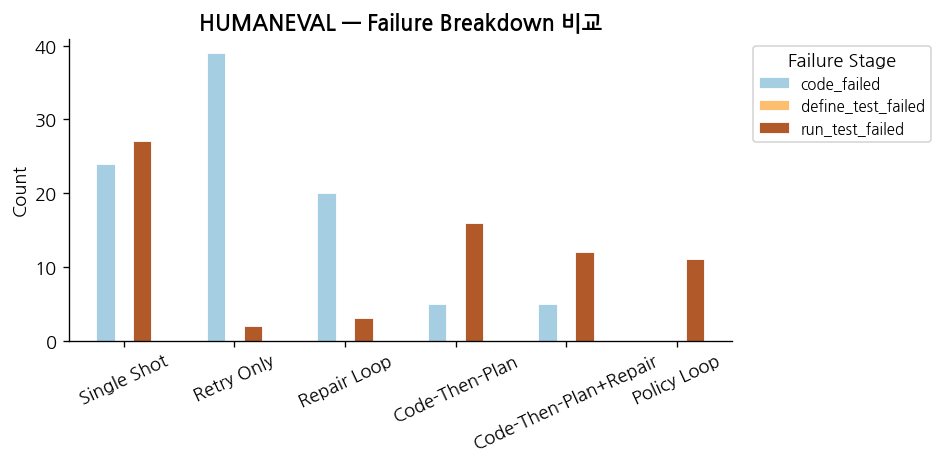

In [21]:
# 8-3. Failure Breakdown 비교 시각화
breakdown_metrics = ['code_failed', 'define_test_failed', 'run_test_failed']

for dataset in available_datasets:
    bd_data = {}
    for method in METHODS:
        key = (dataset, method)
        if key not in summaries:
            continue
        extra = summaries[key].get('extra_summary', {})
        if extra:
            bd_data[METHOD_LABELS[method]] = {k: extra.get(k, 0) for k in breakdown_metrics}
    
    if not bd_data:
        continue
    
    df_bd = pd.DataFrame(bd_data).T
    
    fig, ax = plt.subplots(figsize=(8, 4))
    df_bd.plot(kind='bar', ax=ax, colormap='Paired', edgecolor='white', linewidth=0.5)
    ax.set_title(f'{dataset.upper()} — Failure Breakdown 비교', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Failure Stage', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()